# Временной ряд заказов такси с почасовой агрегацией

**Описание проекта:**   
Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час.

**Цель исследования:**   
Загрузить данные и выполнить их ресемплирование по одному часу, обучить разные модели с различными гиперпараметрами. Проверить данные на тестовой выборке и сделать выводы. Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

**Описание данных:**   
Датасет с временными рядами: каждые 10 минут фиксируется количество заказов


**Ход исследования:**  
- [1. Подготовка данных](#подготовка)
- [2. Анализ данных](#обучение)
- [3. Обучение моделей](#обучение)
- [4. Тестирование модели](#тестирование)
- [5. Вывод](#вывод)

**Общий вывод:**   
Виден тренд на увеличение поездок в течение всего периода анализа. Видна сезонность по часам дня и по дням недели. Однако тест Дики-Фуллера показал нам, что ряд стационарен. Использовались три модели для анализа временных рядов - DecisionTreeRegressor, LinearRegression и Prophet.  RMSE меньше всего у LinearRegression (30.88). Далее идет Prophet (32.38) и DecisionTreeRegressor (35.44). Тестировали на лучшей модели (LinearRegression), на 10% данных от общего ресемплированного датасета. RMSE получился 41.88, что удовлетворяет требования - RMSE должен был получиться меньше 48

<a id="подготовка"></a> 
## Подготовка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, 
                                     TimeSeriesSplit, 
                                     GridSearchCV, 
                                     cross_val_score
                                    )
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

RANDOM_STATE = 42

C:\Users\Roman\.conda\envs\ds_prophet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
try:
    df = pd.read_csv('/datasets/taxi.csv', parse_dates=[0], index_col=[0])
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv', parse_dates=[0], index_col=[0])
    
df.sort_index(inplace = True)

df.head(6)

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32
2018-03-01 00:50:00,21


In [3]:
def opening(df):
    print('ПЕРВЫЕ ПЯТЬ СТРОК')
    display(df.head())
    
    print('ИНФОРМАЦИЯ О ДАННЫХ')
    df.info()
    print('\n')
    
    print('КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ')
    print(df.isna().sum(), '\n')
    
    print('КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %')
    print(df.isna().mean() * 100, '\n')
    
    print('ОПИСАНИЕ ЧИСЛОВЫХ ДАННЫХ')
    print(df.describe(), '\n')
    
    print('КОЛИЧЕСТВО ДУБЛИКАТОВ')
    print(df.duplicated().sum())
        
    print('РАСПРЕДЕЛЕНИЕ ДАННЫХ КОЛИЧЕСТВЕННЫХ СТОЛБЦОВ')
    df.hist(figsize = (15,10))

ПЕРВЫЕ ПЯТЬ СТРОК


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


ИНФОРМАЦИЯ О ДАННЫХ
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
num_orders    0
dtype: int64 

КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %
num_orders    0.0
dtype: float64 

ОПИСАНИЕ ЧИСЛОВЫХ ДАННЫХ
         num_orders
count  26496.000000
mean      14.070463
std        9.211330
min        0.000000
25%        8.000000
50%       13.000000
75%       19.000000
max      119.000000 

КОЛИЧЕСТВО ДУБЛИКАТОВ
26415
РАСПРЕДЕЛЕНИЕ ДАННЫХ КОЛИЧЕСТВЕННЫХ СТОЛБЦОВ


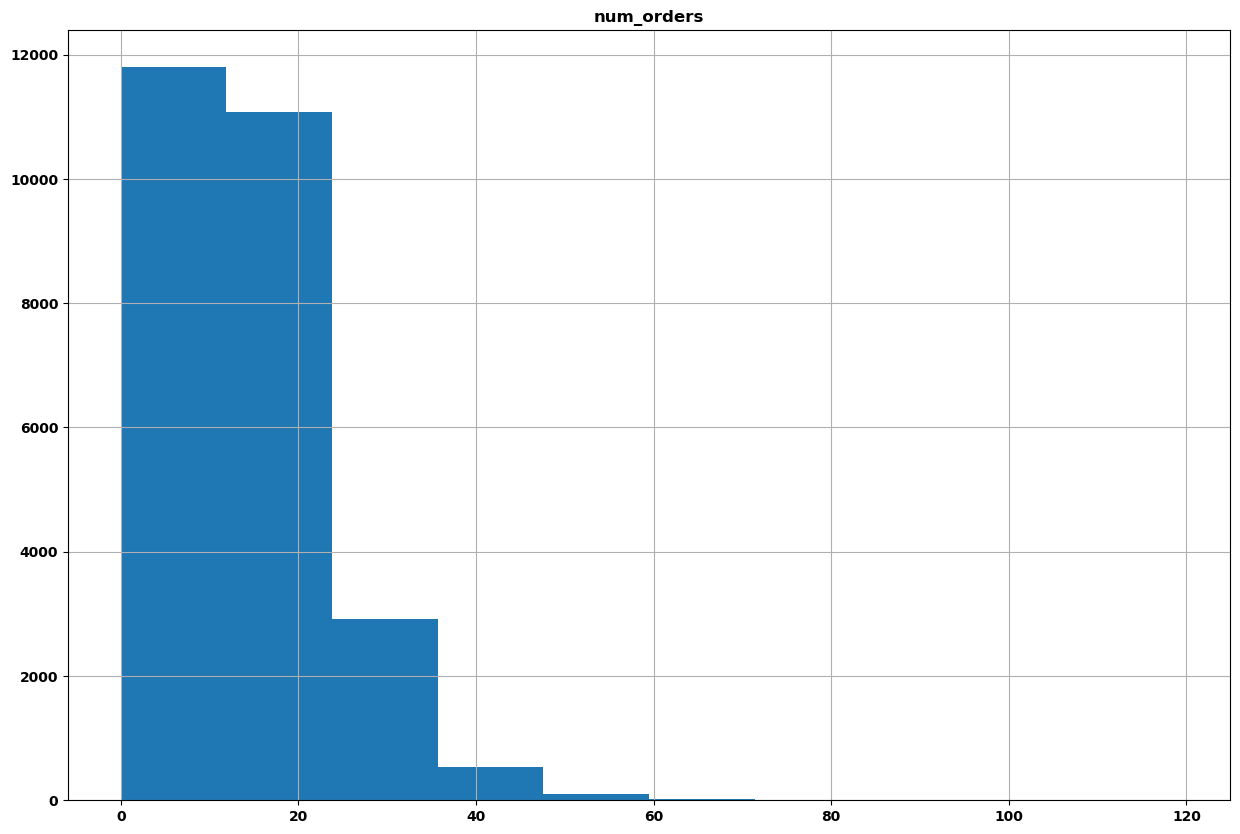

In [4]:
opening(df)

Cделаем ресемпл по одному часу

In [5]:
df = df.resample('1h').sum()
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


**ИТОГ:**
- датасет с данными о заказах такси в аэропортах. 26496 строк. Сразу сделаем даты индексом
- сразу сделаем ресемплирование по 1 часу, проссумируем количество заказов. Итого останется 4416 строк

<a id="анализ"></a>
## Анализ данных

Построим график заказов по каждому часу. Так же для понимания графика нанесем на него среднее количество заказов за всё время - так лучше видно, как двигаются наши закази, в какую сторону по количеству. И синим нанесем скользящее среднее за 48 часов. Так мы тоже хорошо увидим, что заказы в среднем постоянно растут, особенно начиная с Июля

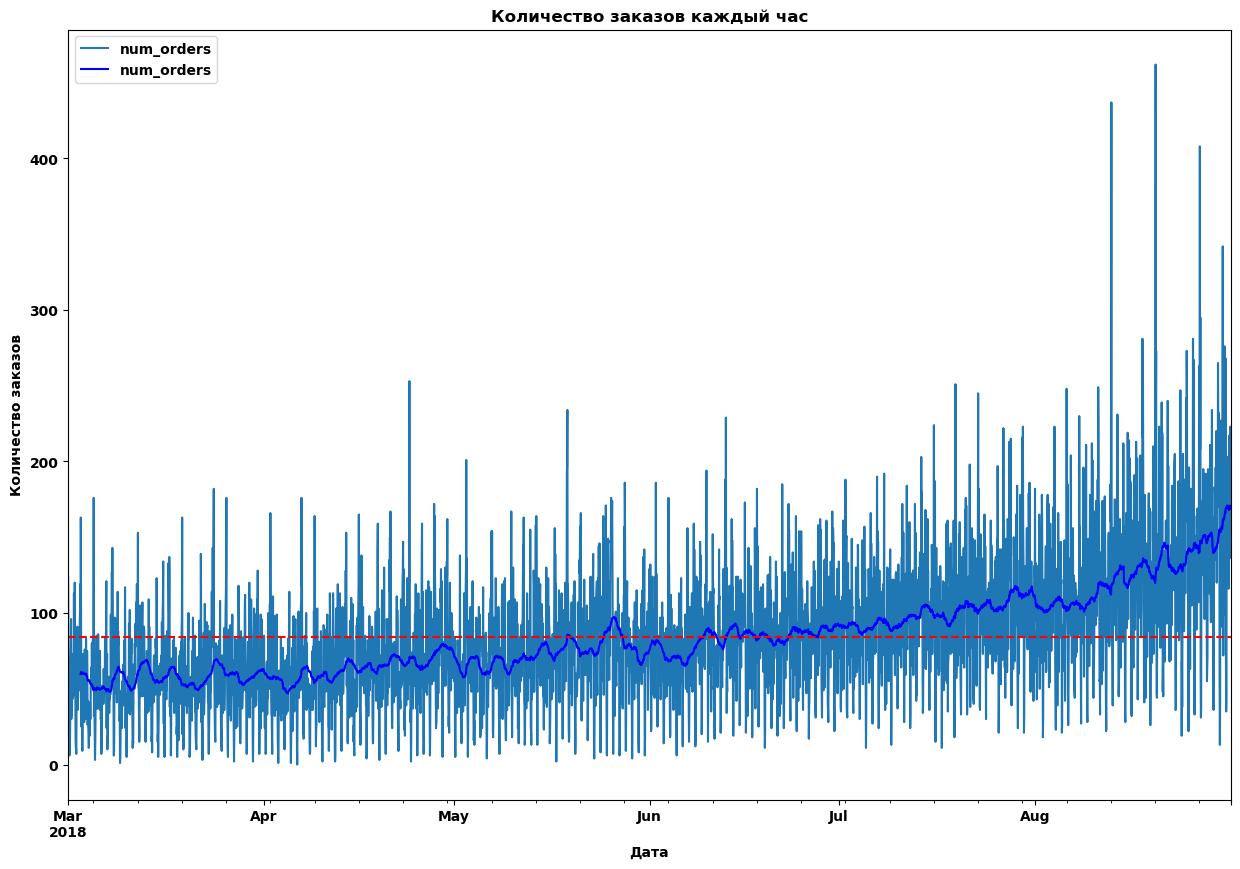

In [6]:
fig, ax = plt.subplots(figsize=(12,6))

df.plot(label='Original', ax=ax, figsize=(15,10))
df.rolling(48).mean().plot(color='blue', ax=ax, figsize=(15,10))
plt.title('Количество заказов каждый час')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.axhline(df['num_orders'].mean(), color='red', linestyle='--');

По данному графику мы не можем сказать, стационарный ряд или нет. Вроде бы идет постоянное повышение, но оне не такое сильное. Проверим тестом Дики-Фуллера:  
**Нулевая гипотеза:** Временной ряд  не стационарен  
**Альтернативная гипотеза** Временной ряд стационарен  

In [7]:
result = adfuller(df)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

ADF Statistic: -3.0689242890279482
p-value: 0.028940051402613506
Critical Values: {'1%': np.float64(-3.431842162413052), '5%': np.float64(-2.8621993540813637), '10%': np.float64(-2.567120978470452)}


p-value < 0.05, Есть основания отвергнуть нулевую гипотезу. Наш ряд стационарен

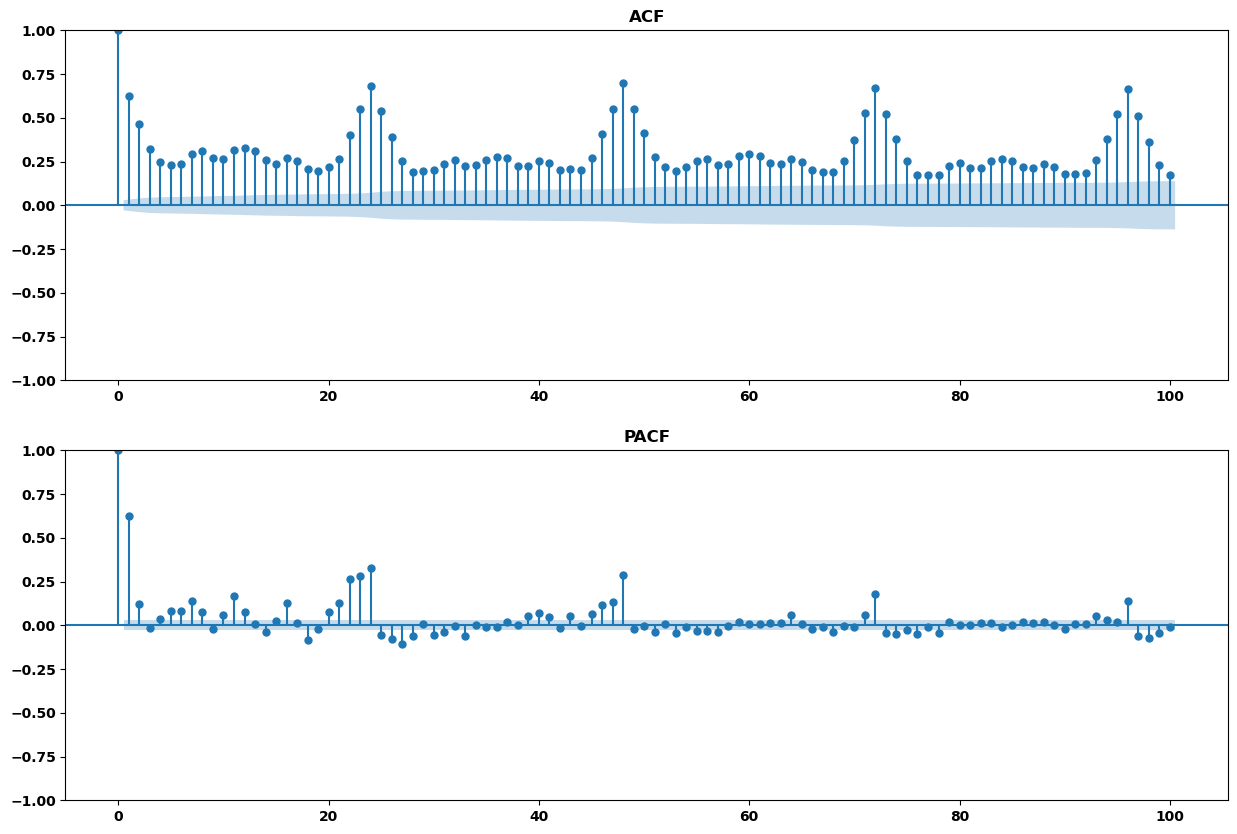

In [8]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plot_acf(df, lags=100, ax=plt.gca(), title='ACF')
plt.subplot(2, 1, 2)
plot_pacf(df, lags=100, ax=plt.gca(), title='PACF');

По графику автокорреляции мы видим, что почти на всём графике значение около 0.25 - это слабая корреляция. Однако каждый 24 лага (а 1 лаг = 1 час) у нас есть всплеск, до 0.75. Это означает о наличие "сезонности"

Посмотрим, в какое время суток среднее количество заказов за всё время исследования

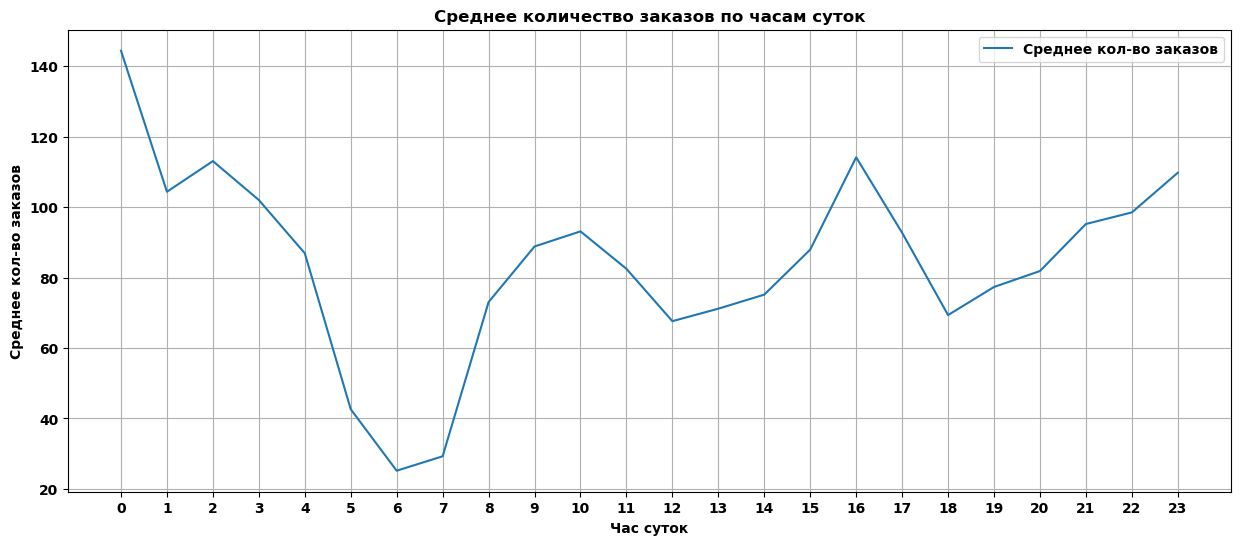

In [9]:
df_hour = df.groupby(df.index.hour).mean()

df_hour.plot(title='Среднее количество заказов по часам суток', figsize=(15,6))
plt.xticks(df_hour.index)
plt.xlabel('Час суток')
plt.ylabel('Среднее кол-во заказов')
plt.grid(True)
plt.legend(['Среднее кол-во заказов']);

Посмотрим на распределение среднего количество заказов в зависимости от дня недели

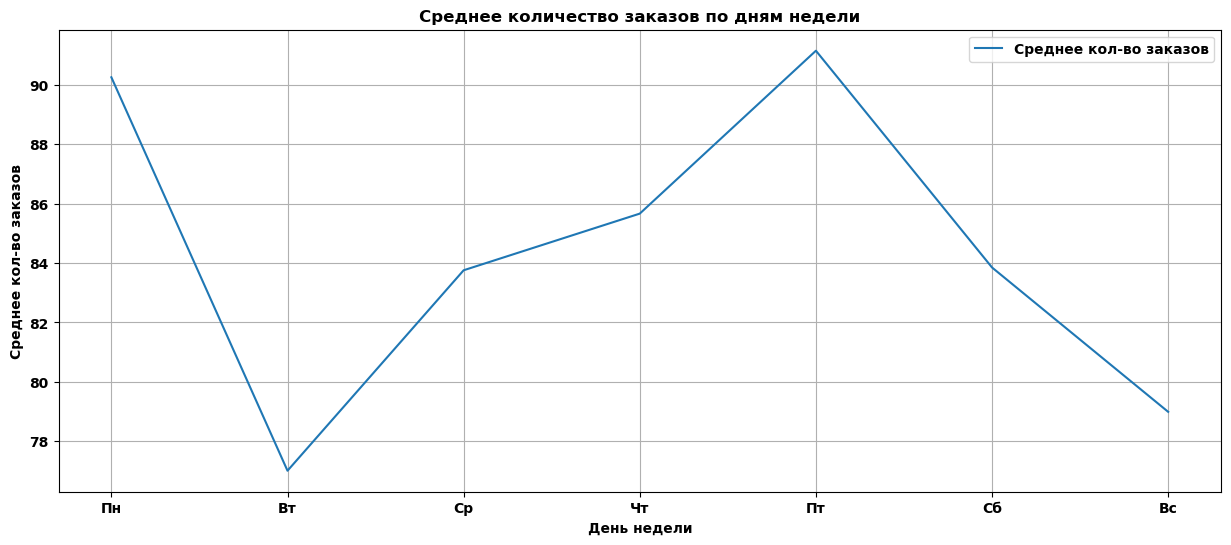

In [10]:
df_dayofweek = df.groupby(df.index.dayofweek).mean()

df_dayofweek.plot(title='Среднее количество заказов по дням недели', figsize=(15,6))
plt.xlabel('День недели')
plt.ylabel('Среднее кол-во заказов')
plt.grid(True)
plt.xticks(ticks=range(7), labels=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
plt.legend(['Среднее кол-во заказов']);

При помощи библиотеки seasonal_decompose поюстрою график Шума, Тренда, Сезонности и исходного ряда

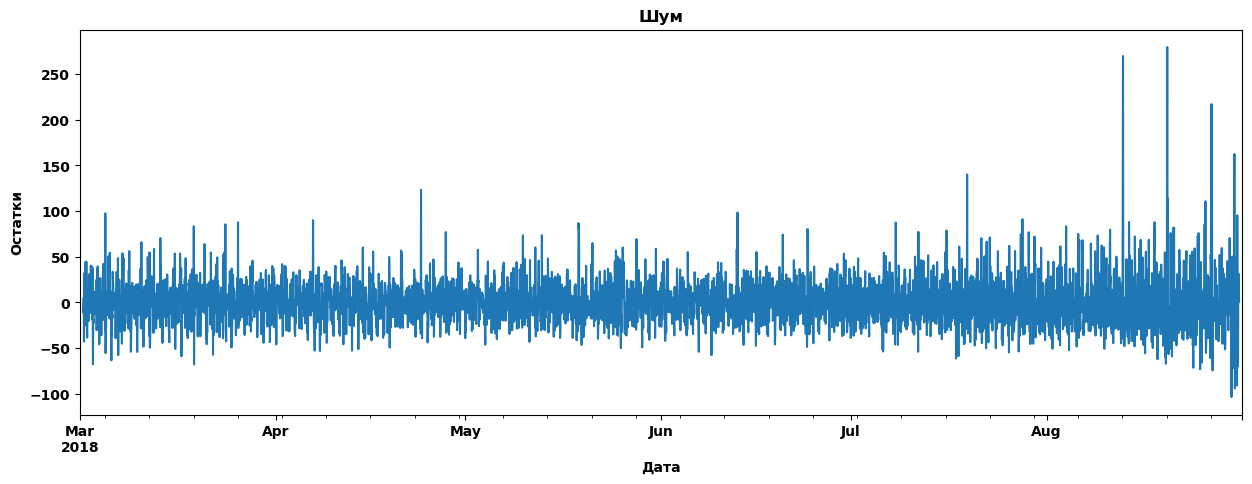

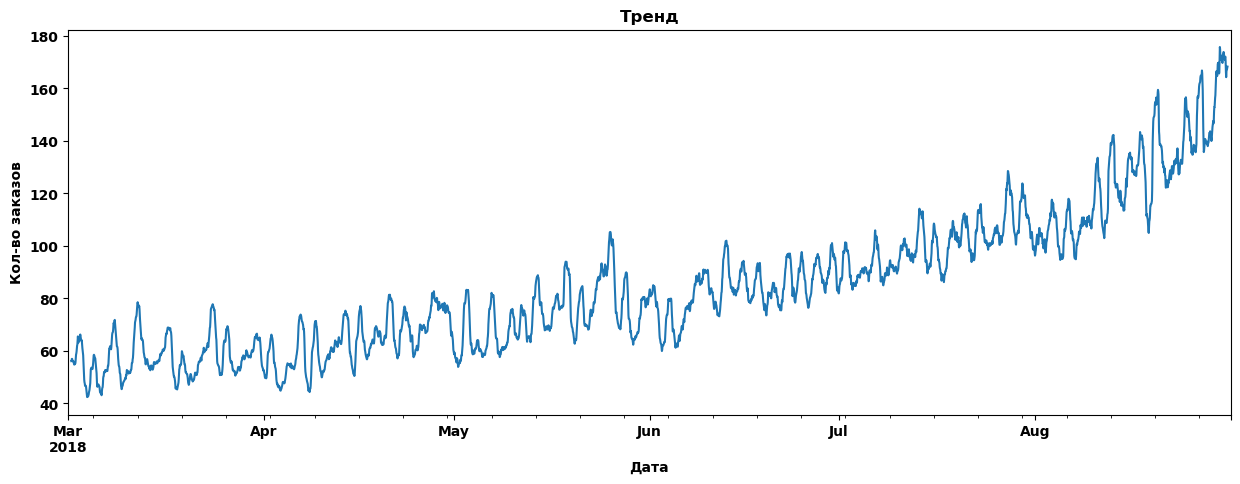

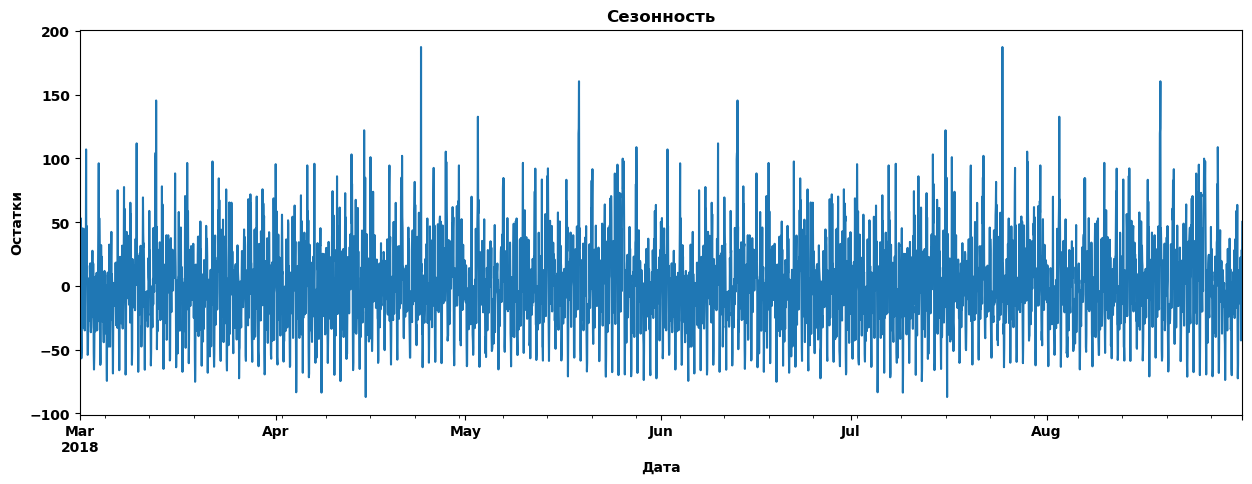

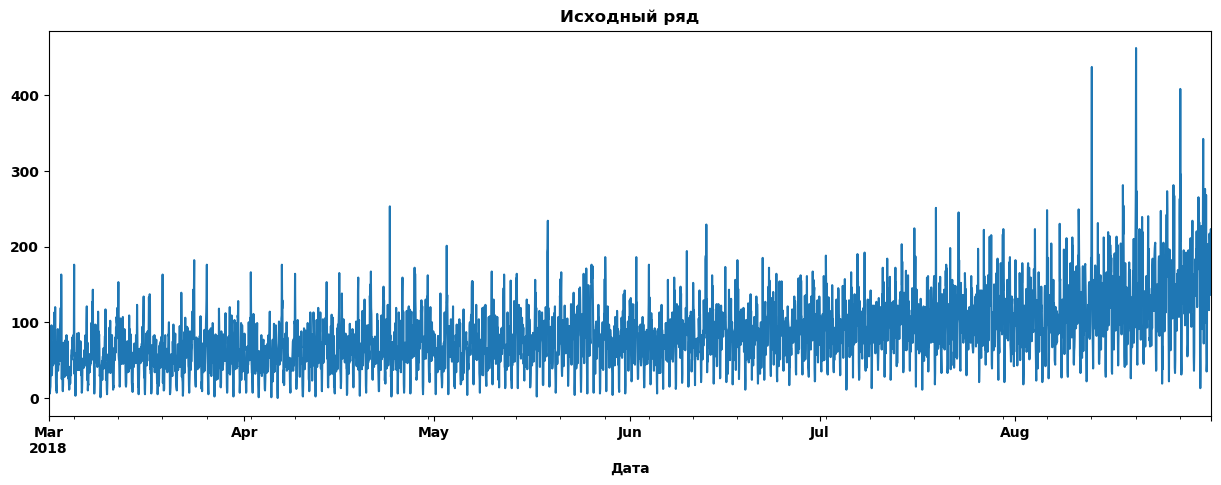

In [11]:
decomposition = seasonal_decompose(df['num_orders'], model='additive')

# Шум. График прямой, около нуля, шума нет
decomposition.resid.plot(figsize=(15,5), title='Шум')
plt.xlabel('Дата')
plt.ylabel('Остатки')
plt.show()

# Тренд. Идет на повышение
decomposition.trend.plot(figsize=(15,5), title='Тренд')
plt.xlabel('Дата')
plt.ylabel('Кол-во заказов')
plt.show()

# Сезонность. Не понимаю немного что тут вообще на рисунке, что всё это означает
seasonal_decompose(df['num_orders'], model='additive', period = 2208).seasonal.plot(figsize=(15,5), title='Сезонность')
plt.xlabel('Дата')
plt.ylabel('Остатки')
plt.show()

# Исходный ряд
decomposition.observed.plot(figsize=(15,5), title='Исходный ряд')
plt.xlabel('Дата')
plt.show()

**ИТОГ:**
- построили график заказов по часам со стартовой даты датасета до конечной. Видим динамику на повышение количества заказов
- при помощи теста Дики-Фуллера выяснили, что ряд стационарен. Хоть и идет среднее количество вверх, но это не существенное увеличение
- на графиках автокорреляции можно говорим о "сезонности" - каждые 24 часа идет всплеск заказов
- видна сезонность по часам и по дням недели

<a id="обучение"></a>
## Обучение моделей

**Первая модель, которую возьмем - DecisionTreeRegressor**

In [12]:
data = df.copy()

def make_features(data, max_lag, rolling_mean_size):
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)
        
    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()
    
    return data

data1 = make_features(data, 50, 10)
data1.head()

,num_orders,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_42,lag_43,lag_44,lag_45,lag_46,lag_47,lag_48,lag_49,lag_50,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,1,124.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,2,85.0,124.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,3,71.0,85.0,124.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,3,4,66.0,71.0,85.0,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
temp, test = train_test_split(data1, shuffle=False, test_size=0.1)
train, valid = train_test_split(temp, shuffle=False, test_size=0.15)
train = train.dropna()

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']
X_valid = valid.drop('num_orders', axis=1)
y_valid = valid['num_orders']
X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

print(f"Размеры (train): {X_train.shape[0] / data1.shape[0] *100:.2f} %")
print(f"Размеры (valid): {X_valid.shape[0] / data1.shape[0] *100:.2f} %")
print(f"Размеры (test): {X_test.shape[0] / data1.shape[0] *100:.2f} %")

# Проверим, что наши данные идут одни за другими:
print(f"\nCтарт train: {X_train.index.min()}, Конец train: {X_train.index.max()}")
print(f"Cтарт valid: {X_valid.index.min()}, Конец valid: {X_valid.index.max()}")
print(f"Cтарт test: {X_test.index.min()}, Конец test: {X_test.index.max()}")

Размеры (train): 75.34 %
Размеры (valid): 13.52 %
Размеры (test): 10.01 %

Cтарт train: 2018-03-03 02:00:00, Конец train: 2018-07-19 16:00:00
Cтарт valid: 2018-07-19 17:00:00, Конец valid: 2018-08-13 13:00:00
Cтарт test: 2018-08-13 14:00:00, Конец test: 2018-08-31 23:00:00


In [14]:
params = {
    'splitter': ['best'],
    'max_depth': [7, 10, 15],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [18, 20, 22],
    'max_features': [None],
    'max_leaf_nodes': [56, 57, 58],
    'min_impurity_decrease': [0.0],
    'ccp_alpha': [0.0]}

model_tree = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), 
                          param_grid=params, 
                          cv=TimeSeriesSplit(n_splits=3)
                         )

model_tree.fit(X_train, y_train)

model_tree.best_params_

{'ccp_alpha': 0.0,
 'max_depth': 7,
 'max_features': None,
 'max_leaf_nodes': 56,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 22,
 'min_samples_split': 2,
 'splitter': 'best'}

Посмотрим на топ-15 важнейших признаков для обучения модели

In [15]:
importances_tree = pd.Series(
            model_tree.best_estimator_.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances_tree.head(15)

lag_48          0.564554
lag_24          0.148700
rolling_mean    0.077274
hour            0.043300
lag_2           0.027234
lag_1           0.019898
lag_41          0.014055
lag_49          0.012999
lag_35          0.009263
lag_11          0.009084
lag_20          0.007006
lag_34          0.006301
lag_7           0.006175
lag_6           0.005358
lag_33          0.004945
dtype: float64

Запустим обучение DecisionTreeRegressor снова, выбрав только топ-15 признаков

In [16]:
top_imp = importances_tree.head(15).index.tolist()

model_tree2 = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), 
                          param_grid=params, 
                          cv=TimeSeriesSplit(n_splits=3)
                         )

model_tree2.fit(X_train[top_imp], y_train)

model_tree2.best_params_

{'ccp_alpha': 0.0,
 'max_depth': 15,
 'max_features': None,
 'max_leaf_nodes': 56,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 22,
 'min_samples_split': 2,
 'splitter': 'best'}

Проверим на валидационной выборке

In [17]:
best_tree = model_tree2.best_estimator_
preds_tree_valid = best_tree.predict(X_valid[top_imp])

rmse_tree_valid = np.sqrt(mean_squared_error(y_valid, preds_tree_valid))
print(f"DecisionTreeRegressor RMSE (valid): {rmse_tree_valid:.2f}")

DecisionTreeRegressor RMSE (valid): 35.44


**Вторая модель - LinearRegression**

In [18]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_valid_pred = model_lr.predict(X_valid)

rmse_valid_lr = np.sqrt(mean_squared_error(y_valid, y_valid_pred))

print(f"LinearRegression RMSE (valid): {rmse_valid_lr:.2f}")

LinearRegression RMSE (valid): 30.88


**Третья модель - Prophet**

In [19]:
df_prophet = data['num_orders'].reset_index().copy()
df_prophet.columns = ['ds', 'y']
df_prophet

,ds,y
0,2018-03-01 00:00:00,124
1,2018-03-01 01:00:00,85
2,2018-03-01 02:00:00,71
3,2018-03-01 03:00:00,66
4,2018-03-01 04:00:00,43
...,...,...
4411,2018-08-31 19:00:00,136
4412,2018-08-31 20:00:00,154
4413,2018-08-31 21:00:00,159
4414,2018-08-31 22:00:00,223


In [20]:
split_test = int(len(df_prophet) * 0.9)
temp = df_prophet[:split_test]
test_prophet = df_prophet[split_test:]

split_valid = int(len(temp) * 0.85)
train_prophet = temp[:split_valid]
valid_prophet = temp[split_valid:]

print(f"Размеры (train): {train_prophet.shape[0] / data1.shape[0] *100:.2f} %")
print(f"Размеры (valid): {valid_prophet.shape[0] / data1.shape[0] *100:.2f} %")
print(f"Размеры (test): {test_prophet.shape[0] / data1.shape[0] *100:.2f} %")

# Проверим, что наши данные идут одни за другими:
print(f"\nCтарт train: {train_prophet['ds'].min()}, Конец train: {train_prophet['ds'].max()}")
print(f"Cтарт valid: {valid_prophet['ds'].min()}, Конец valid: {valid_prophet['ds'].max()}")
print(f"Cтарт test: {test_prophet['ds'].min()}, Конец test: {test_prophet['ds'].max()}")

Размеры (train): 76.47 %
Размеры (valid): 13.52 %
Размеры (test): 10.01 %

Cтарт train: 2018-03-01 00:00:00, Конец train: 2018-07-19 16:00:00
Cтарт valid: 2018-07-19 17:00:00, Конец valid: 2018-08-13 13:00:00
Cтарт test: 2018-08-13 14:00:00, Конец test: 2018-08-31 23:00:00


In [21]:
model = Prophet(
    seasonality_mode='additive',
    daily_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=4,
    seasonality_prior_scale=20.0
)
model.fit(train_prophet)

future_valid = model.make_future_dataframe(periods=len(valid_prophet), freq='h')
forecast_valid = model.predict(future_valid)

p_valid = valid_prophet.set_index('ds').join(forecast_valid.set_index('ds')[['yhat']][-len(valid_prophet):])

rmse_valid = np.sqrt(mean_squared_error(p_valid['y'], p_valid['yhat']))
print(f"RMSE на валидационной выборке: {rmse_valid:.2f}")

11:51:41 - cmdstanpy - INFO - Chain [1] start processing
11:51:41 - cmdstanpy - INFO - Chain [1] done processing


RMSE на валидационной выборке: 32.38


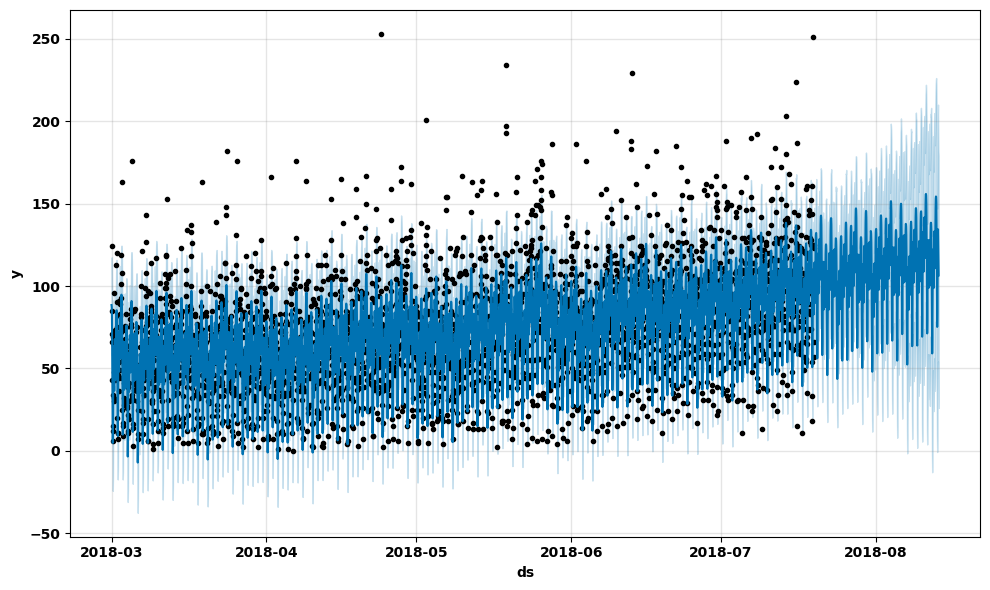

In [22]:
ax = model.plot(forecast_valid)

**ИТОГ:**  
Мы обучали три модели с различными гиперпараметрами, проверяли их на валидационной выборке. Самое низкое RMSE получилось у  LinearRegression (30.88). Далее идет Prophet (32.38) и DecisionTreeRegressor (35.44)

<a id="тестирование"></a>
## Тестирование модели

**LinearRegression**  
Теперь соединим train + valid, еще раз обучим и узнаем итоговый RMSE, который должен быть по условиям менее 48.00. Из трёх моделей выше самое низкое RMSE на валидационной выборке получилось у LinearRegression, значит ее и будет тестировать

In [23]:
X_train_valid = pd.concat([X_train, X_valid], axis=0)
y_train_valid = pd.concat([y_train, y_valid], axis=0)

model_lr.fit(X_train_valid, y_train_valid)

y_test_pred = model_lr.predict(X_test)

rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"RMSE (test): {rmse_test_lr:.2f}")

RMSE (test): 41.88


<a id="вывод"></a>
## Вывод

У нас были данные о заказах такси в аэропортах. 
1) Было сделано ресемприлование данных, сумма поездок по каждому часу  
2) Сделан анализ данных - виден тренд на увеличение поездок в течение всего периода анализа. Видна сезонность по часам дня и по дням недели. Однако тест Дики-Фуллера показал нам, что ряд стационарен.
3) Были введены дополнительные признаки (день недели, час, лаги + скользящее среднее) для машинного обучения  
4) Использовались три модели для анализа временных рядов и дальшейшего прогнозирования - DecisionTreeRegressor, LinearRegression и Prophet  
5) Данные проверяли на валидацонной выборке. RMSE меньше всего у LinearRegression (30.88). Далее идет Prophet (32.38) и DecisionTreeRegressor (35.44)  
6) Тестировали на лучшей модели (LinearRegression), на 10% данных от общего ресемплированного датасета. RMSE получился 41.88, что удовлетворяет требования - RMSE должен был получиться меньше 48  